In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from the_well.data import WellDataset
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")
print(f"Torch: {torch.__version__}  |  Torchvision: {__import__('torchvision').__version__}")

Dispositivo: cuda
Torch: 2.11.0+cu128  |  Torchvision: 0.26.0+cu128


In [ ]:
class SpectralConv2d(nn.Module):
    def __init__(self,
                 in_channels,
                 out_channels,
                 modes1,
                 modes2):
        super().__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels

        self.modes1 = modes1
        self.modes2 = modes2

        scale = np.sqrt(2) / (in_channels * out_channels)

        self.weights = nn.Parameter(
            scale * torch.randn(
                in_channels,
                out_channels,
                modes1,
                modes2,
                dtype=torch.cfloat
            )
        )

    def forward(self, x):
        batchsize = x.shape[0]

        x_ft = torch.fft.rfft2(x)

        out_ft = torch.zeros(
            batchsize,
            self.out_channels,
            x.size(-2),
            x.size(-1) // 2 + 1,
            dtype=torch.cfloat,
            device=x.device
        )

        out_ft[:, :, :self.modes1, :self.modes2] = torch.einsum(
            "bixy,ioxy->boxy",
            x_ft[:, :, :self.modes1, :self.modes2],
            self.weights
        )

        x = torch.fft.irfft2(
            out_ft,
            s=(x.size(-2), x.size(-1))
        )

        return x
   
    
class FourierLayer2d(nn.Module):
    def __init__(self,
                 width,
                 modes1,
                 modes2):
        super().__init__()

        self.spectral = SpectralConv2d(
            width,
            width,
            modes1,
            modes2
        )

        self.pointwise = nn.Conv2d(
            width,
            width,
            kernel_size=1
        )

    def forward(self, x):

        return (
            self.spectral(x)
            + self.pointwise(x)
        )
    

class FNO2d(nn.Module):
    def __init__(
        self,
        modes1=16,
        modes2=16,
        width=64,
        in_dim=3,
        out_dim=1,
        depth=4
    ):
        super().__init__()

        self.lift = nn.Linear(
            in_dim,
            width
        )

        self.layers = nn.ModuleList([
            FourierLayer2d(
                width,
                modes1,
                modes2
            )
            for _ in range(depth)
        ])

        self.proj1 = nn.Linear(
            width,
            128
        )

        self.proj2 = nn.Linear(
            128,
            out_dim
        )

    def forward(self, x):
        # (B,nx,ny,in_dim)
        x = self.lift(x)

        # (B,width,nx,ny)
        x = x.permute(
            0, 3, 1, 2
        )

        for layer in self.layers:
            x = layer(x)
            x = F.gelu(x)

        # (B,nx,ny,width)
        x = x.permute(
            0, 2, 3, 1
        )

        x = self.proj1(x)
        x = F.gelu(x)

        x = self.proj2(x)

        return x

In [4]:
train_dataset = WellDataset(
    path="/mnt/storage_C1/BILL_pino/the_well/datasets/helmholtz_staircase",
    well_split_name="train"
)

sample = train_dataset[0]

for k, v in sample.items():
    if torch.is_tensor(v):
        print(k, v.shape, v.dtype)
    else:
        print(k, type(v))

input_fields torch.Size([1, 1024, 256, 2]) torch.float32
output_fields torch.Size([1, 1024, 256, 2]) torch.float32
constant_fields torch.Size([1024, 256, 1]) torch.float32
constant_scalars torch.Size([1]) torch.float32
boundary_conditions torch.Size([2, 2]) torch.float32
space_grid torch.Size([1024, 256, 2]) torch.float32
input_time_grid torch.Size([1]) torch.float32
output_time_grid torch.Size([1]) torch.float32


/home/al.igor.zwirtes/Documentos/AV2_ML2_IMPA/env/lib/python3.12/site-packages/the_well/data/datasets.py:736: RuntimeWarning: Only axis-aligned boundary fully supported. Boundary for axis counted as `open` or `periodic` if any part of it is and `wall` otherwise.If this does not fit your desired usecase, set `boundary_return_type=None`.
  warnings.warn(


In [ ]:
class HelmholtzDataset(torch.utils.data.Dataset):
    def __init__(self, ds):
        self.ds = ds

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        sample = self.ds[idx]

        x = torch.cat([
            sample["input_fields"][0],
            sample["constant_fields"],
            sample["space_grid"]
        ], dim=-1)

        y = sample["output_fields"][0]

        return x.float(), y.float()

In [6]:
train_ds = HelmholtzDataset(train_dataset)

train_loader = DataLoader(
    train_ds,
    batch_size=1,
    shuffle=True,
    num_workers=4
)

In [7]:
model = FNO2d(
    modes1=16,
    modes2=16,
    width=32,
    in_dim=5,
    out_dim=2,
    depth=4
).cuda()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3
)

criterion = nn.MSELoss()

In [8]:
torch.backends.cuda.matmul.allow_tf32 = True
torch.set_float32_matmul_precision("high")

epochs = 100

for epoch in range(epochs):

    model.train()

    running_loss = 0.0

    pbar = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{epochs}",
        leave=True
    )

    for batch_idx, (x, y) in enumerate(pbar):

        x = x.cuda(non_blocking=True)
        y = y.cuda(non_blocking=True)

        pred = model(x)

        loss = criterion(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        avg_loss = running_loss / (batch_idx + 1)

        pbar.set_postfix({
            "loss": f"{avg_loss:.6f}"
        })

    print(
        f"Epoch {epoch+1:03d} | "
        f"loss = {running_loss/len(train_loader):.6f}"
    )

Epoch 1/100: 100%|██████████| 20384/20384 [13:46<00:00, 24.66it/s, loss=0.008606]


Epoch 001 | loss = 0.008606


Epoch 2/100: 100%|██████████| 20384/20384 [10:18<00:00, 32.94it/s, loss=0.032408]


Epoch 002 | loss = 0.032408


Epoch 3/100: 100%|██████████| 20384/20384 [09:47<00:00, 34.70it/s, loss=0.034978]


Epoch 003 | loss = 0.034978


Epoch 4/100:  46%|████▋     | 9455/20384 [04:10<04:49, 37.77it/s, loss=0.033020]


KeyboardInterrupt: 

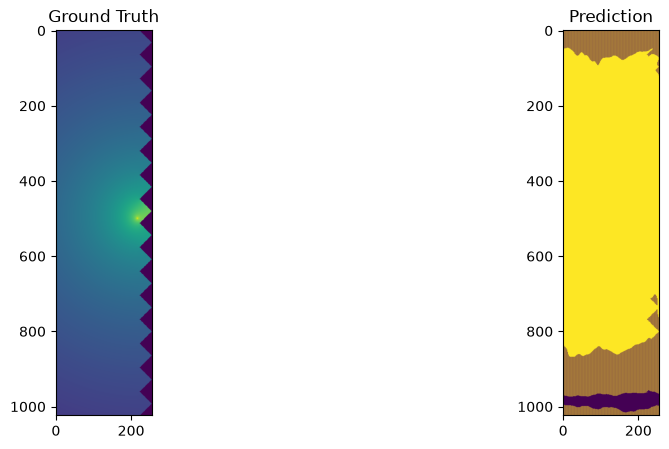

In [16]:
x, y = train_ds[100]

x = x.unsqueeze(0).cuda()

model.eval()

with torch.no_grad():
    pred = model(x)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(y[:,:,0])
plt.title("Ground Truth")

plt.subplot(1,2,2)
plt.imshow(pred[0,:,:,0].cpu())
plt.title("Prediction")

plt.show()

In [17]:
pred_flat = pred.cpu().reshape(-1)
y_flat = y.reshape(-1)

rel_l2 = (
    torch.norm(pred_flat - y_flat)
    /
    torch.norm(y_flat)
)

print(rel_l2.item())

0.9773562550544739
